# TravClan Business Analyst Assessment – Set C
### Candidate: Surbhi Jain

This notebook contains:
- Section 1: Data Quality Checks
- Section 2: VIP vs Volume Strategy
- Section 3: SQL Challenge
- Section 4: Multi-Currency Revenue Reporter

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
!pip install matplotlib-venn

In [79]:
df = pd.read_csv(
    "hotel_bookings.csv",
    keep_default_na=False
)

df.shape

(12000, 28)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             12000 non-null  int64  
 1   customer_id            12000 non-null  int64  
 2   customer_name          12000 non-null  object 
 3   customer_segment       12000 non-null  object 
 4   customer_signup_date   12000 non-null  object 
 5   customer_home_city     12000 non-null  object 
 6   customer_loyalty_tier  12000 non-null  object 
 7   property_id            12000 non-null  int64  
 8   property_name          12000 non-null  object 
 9   property_city          12000 non-null  object 
 10  property_star_rating   12000 non-null  int64  
 11  property_type          12000 non-null  object 
 12  property_total_rooms   12000 non-null  int64  
 13  booking_date           12000 non-null  object 
 14  checkin_date           12000 non-null  object 
 15  ch

In [81]:
df.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,...,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,,
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,...,4,Corporate Portal,4021.62,0.00,,16086.48,Net Banking,Cancelled,,
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,...,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,,
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


In [82]:
df['customer_loyalty_tier'].value_counts(dropna=False)

,count
customer_loyalty_tier,
None,5571
Silver,3135
Gold,2100
Platinum,1194


Convert Date Columns

In [83]:
date_cols = [
    'customer_signup_date',
    'booking_date',
    'checkin_date',
    'checkout_date',
    'review_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   booking_id             12000 non-null  int64         
 1   customer_id            12000 non-null  int64         
 2   customer_name          12000 non-null  object        
 3   customer_segment       12000 non-null  object        
 4   customer_signup_date   12000 non-null  datetime64[ns]
 5   customer_home_city     12000 non-null  object        
 6   customer_loyalty_tier  12000 non-null  object        
 7   property_id            12000 non-null  int64         
 8   property_name          12000 non-null  object        
 9   property_city          12000 non-null  object        
 10  property_star_rating   12000 non-null  int64         
 11  property_type          12000 non-null  object        
 12  property_total_rooms   12000 non-null  int64         
 13  b

**VALIDATION**

In [85]:
# Invalid stays
invalid_stays = df[
    df['checkout_date'] <= df['checkin_date']
]

len(invalid_stays)

120

In [86]:
# Booking before signup

booking_before_signup = df[
    df['booking_date'] < df['customer_signup_date']
]

len(booking_before_signup)

163

In [87]:
# Zero rooms

zero_rooms = df[
    df['num_rooms'] == 0
]

len(zero_rooms)

60

In [88]:
# Duplicate property names

duplicate_property_names = (
    df.groupby('property_name')['property_id']
      .nunique()
      .reset_index()
)

duplicate_property_names[
    duplicate_property_names['property_id'] > 1
]

,property_name,property_id
20,Hilltop Inn,2
42,Royal Orchid,2
49,Sea Breeze Resort,2
50,The Grand Plaza,2


In [89]:
# Reviews on cancelled bookings

cancelled_reviews = df[
    (df['booking_status'] == 'Cancelled')
    &
    (df['review_rating'] != '')
]

len(cancelled_reviews)

50

In [90]:
# Corporate review mismatch

df.groupby('customer_segment')['review_rating'].describe()

,count,unique,top,freq
customer_segment,,,,
Corporate,2892,9,,1605
Group,1408,6,,818
Individual,7700,6,,4431


---
# Section 1 – Data Quality Checks

C1. How many bookings have num rooms = 0? What does this imply about the upstream pipeline?

In [91]:
zero_rooms = df[
    df['num_rooms'] == 0
]

zero_room_count = len(zero_rooms)

print(
    "Bookings with zero rooms:",
    zero_room_count
)

Bookings with zero rooms: 60


In [92]:
zero_rooms.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
55,100055,723,Customer_723,Individual,2023-01-06,Goa,None,16,Banyan Residency,Delhi,...,3,OTA,2505.28,960.13,WELCOME,0.0,Debit Card,Completed,,NaT
101,100101,73,Customer_73,Group,2023-07-08,Chennai,None,40,Mango Lodge,Bangalore,...,2,Corporate Portal,9289.49,0.00,NONE,0.0,Debit Card,Completed,5.0,2024-06-14
372,100372,657,Customer_657,Individual,2023-12-08,Jaipur,Silver,7,Royal Orchid,Chennai,...,1,OTA,2369.62,0.00,,0.0,Net Banking,Cancelled,,NaT
385,100385,13,Customer_13,Individual,2023-11-25,Chennai,Silver,35,Maple Retreat,Bangalore,...,1,Travel Agent,8848.19,0.00,,0.0,UPI,Completed,5.0,2024-05-24
403,100403,447,Customer_447,Individual,2022-02-19,Kochi,Platinum,27,Saffron Residency,Pune,...,3,Travel Agent,5306.07,0.00,NONE,0.0,UPI,Cancelled,,NaT


There are 60 bookings with num_rooms = 0.

This indicates a data quality issue because
a booking cannot exist without any room
being reserved.

The finding suggests missing validation
checks in the booking pipeline.

C2. How many bookings have booking date earlier than customer signup date? Give two plausible explanations
— not all of which mean ‘data corruption’.

In [93]:
booking_before_signup = df[
    df['booking_date']
    <
    df['customer_signup_date']
]

booking_before_signup_count = len(
    booking_before_signup
)

print(
    "Bookings before signup:",
    booking_before_signup_count
)

Bookings before signup: 163


In [94]:
booking_before_signup.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
73,100073,1,Customer_1,Individual,2022-02-04,Jaipur,Silver,46,Coral Manor,Kochi,...,1,Corporate Portal,2044.52,0.00,,2044.52,Net Banking,Cancelled,,NaT
154,100154,145,Customer_145,Group,2023-10-17,Delhi,Platinum,43,Indigo Lodge,Bangalore,...,1,Corporate Portal,4284.20,0.00,,8568.40,Net Banking,Cancelled,,NaT
296,100296,565,Customer_565,Corporate,2023-11-17,Manali,Silver,35,Maple Retreat,Bangalore,...,5,Corporate Portal,9124.74,0.00,NONE,45623.70,Net Banking,Completed,,NaT
361,100361,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,9,Crimson Retreat,Udaipur,...,3,Corporate Portal,15764.96,0.00,NONE,94589.76,UPI,Completed,4.0,2024-01-11
420,100420,293,Customer_293,Individual,2022-07-09,Delhi,Silver,8,Royal Orchid,Goa,...,1,OTA,20940.76,5737.72,APPDEAL,15203.04,Net Banking,Completed,5.0,2024-06-11


1:
Customers may have existed in a legacy
system and their signup dates were
updated during migration.

2:
Customers may have booked as guests and
created accounts later.

Although this represents a temporal
integrity issue, it does not necessarily
indicate data corruption.

C3. What % of bookings have no review (review rating missing)? Break down by booking status — does the
pattern make sense?

In [95]:
# Missing reviews

missing_review_pct = (
    df['review_rating']
    .eq('')
    .mean()
    * 100
)

print(
    "Missing Review Percentage:",
    round(missing_review_pct,2),
    "%"
)

Missing Review Percentage: 57.12 %


In [96]:
review_breakdown = (
    df.groupby('booking_status')
      ['review_rating']
      .apply(
          lambda x:
          (x=='').mean()*100
      )
)

review_breakdown

,review_rating
booking_status,
Cancelled,97.827976
Completed,45.398050
No-Show,100.000000


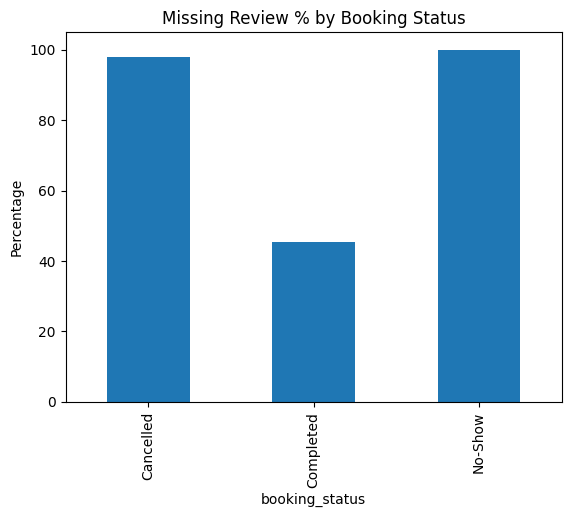

In [97]:
review_breakdown.plot(
    kind='bar'
)

plt.title(
    "Missing Review % by Booking Status"
)

plt.ylabel(
    "Percentage"
)

plt.show()

57.12% of bookings have no review.

Completed bookings have the lowest
missing-review percentage because guests
actually stayed and could provide
feedback.

Cancelled bookings rarely contain
reviews because the stay never occurred.

No-Show bookings have no reviews because
customers never checked in.

In [98]:
# Invalid Stays

invalid_stays = df[
    df['checkout_date']
    <=
    df['checkin_date']
]

print(
    "Invalid stays:",
    len(invalid_stays)
)

Invalid stays: 120


In [99]:
# Reviews on Cancelled Bookings
cancelled_reviews = df[
    (df['booking_status']=='Cancelled')
    &
    (df['review_rating']!='')
]

print(
    "Cancelled bookings with reviews:",
    len(cancelled_reviews)
)

Cancelled bookings with reviews: 50


In [100]:
# Duplicate Property Names
duplicate_properties = (
    df.groupby('property_name')
      ['property_id']
      .nunique()
      .reset_index()
)

duplicate_properties[
    duplicate_properties['property_id'] > 1
]

,property_name,property_id
20,Hilltop Inn,2
42,Royal Orchid,2
49,Sea Breeze Resort,2
50,The Grand Plaza,2


---
# Section 2 – Case Study: The VIP-vs-Volume Strategy

In [101]:
# Completed Bookings Dataset because Only Completed bookings count as
#  realized revenue.

completed = df[
    df['booking_status'] == 'Completed'
].copy()

completed.shape

(9333, 28)

**C1 — DEFINE VIP THREE WAYS**

VIP Definition 1

In [102]:
# Top 10% Customers by Total Spend

spend_df = (
    completed.groupby('customer_id')
    .agg(
        total_spend=('total_amount','sum')
    )
    .reset_index()
)

spend_df.head()

,customer_id,total_spend
0,1,102321.37
1,2,170558.80
2,3,277220.94
3,4,431885.00
4,5,425610.30


In [103]:
vip_spend = set(
    spend_df.nlargest(
        int(len(spend_df)*0.10),
        'total_spend'
    )['customer_id']
)

len(vip_spend)

80

VIP Definition 2

In [104]:
# Top 10% Customers by Booking Count

booking_df = (
    completed.groupby('customer_id')
    .size()
    .reset_index(name='booking_count')
)

booking_df.head()

,customer_id,booking_count
0,1,8
1,2,7
2,3,17
3,4,10
4,5,13


In [105]:
vip_booking = set(
    booking_df.nlargest(
        int(len(booking_df)*0.10),
        'booking_count'
    )['customer_id']
)

len(vip_booking)

80

VIP Definition 3

In [106]:
# Top 10% Customers by LTV Rate

today = completed['booking_date'].max()

ltv_df = (
    completed.groupby('customer_id')
    .agg({
        'total_amount':'sum',
        'customer_signup_date':'min'
    })
)

In [107]:
ltv_df['months_since_signup'] = (
    (today - ltv_df['customer_signup_date'])
    .dt.days
    / 30
)

In [108]:
ltv_df['months_since_signup'] = (
    ltv_df['months_since_signup']
    .replace(0,1)
)

In [109]:
ltv_df['ltv_rate'] = (
    ltv_df['total_amount']
    /
    ltv_df['months_since_signup']
)

In [110]:
vip_ltv = set(
    ltv_df.nlargest(
        int(len(ltv_df)*0.10),
        'ltv_rate'
    ).index
)

len(vip_ltv)

80

In [111]:
# OVERLAP ANALYSIS

all_three = (
    vip_spend
    &
    vip_booking
    &
    vip_ltv
)

len(all_three)

10

In [112]:
exactly_two = (
    (vip_spend & vip_booking)
    |
    (vip_spend & vip_ltv)
    |
    (vip_booking & vip_ltv)
) - all_three

len(exactly_two)

54

In [113]:
only_spend = vip_spend - vip_booking - vip_ltv

only_booking = vip_booking - vip_spend - vip_ltv

only_ltv = vip_ltv - vip_spend - vip_booking

only_one = (
    len(only_spend)
    +
    len(only_booking)
    +
    len(only_ltv)
)

print(
    "Customers in only one VIP definition:",
    only_one
)

Customers in only one VIP definition: 102


In [126]:
overlap_summary = pd.DataFrame({
    'Category': [
        'All Three',
        'Exactly Two',
        'Only One'
    ],
    'Customers': [
        len(all_three),
        len(exactly_two),
        only_one
    ]
})

overlap_summary

,Category,Customers
0,All Three,10
1,Exactly Two,54
2,Only One,102


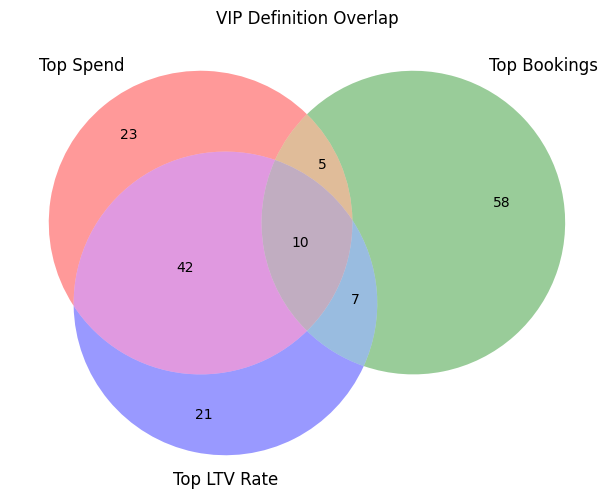

In [114]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

venn3(
    [
        vip_spend,
        vip_booking,
        vip_ltv
    ],
    (
        'Top Spend',
        'Top Bookings',
        'Top LTV Rate'
    )
)

plt.title(
    'VIP Definition Overlap'
)

plt.show()

## C1 Summary

| Metric | Count |
|----------|----------:|
| Top 10% by Spend | 80 |
| Top 10% by Booking Count | 80 |
| Top 10% by LTV Rate | 80 |
| Present in all three | 10 |
| Present in exactly two | 54 |
| Present in only one | 112 |

### Key Insight
VIP status varies significantly depending on the chosen definition, highlighting the importance of selecting a business-aligned VIP framework.

**C2 VIP Risk Profile**

Step 1 – Select VIP Definition

In [115]:
# We will use VIP Definition 1:
# Top 10% customers by Total Spend
# This definition is most relevant because
# it directly impacts platform revenue.

completed['vip_spend'] = (
    completed['customer_id']
    .isin(vip_spend)
)

completed.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date,vip_spend
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,NaT,False
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21,False
6,100006,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,37,Olive Lodge,Udaipur,...,OTA,3286.32,2625.92,WELCOME,10519.36,Debit Card,Completed,,NaT,False
7,100007,85,Customer_85,Individual,2022-07-25,Udaipur,None,45,Cedar Heights,Udaipur,...,Corporate Portal,4152.34,0.00,,8304.68,Credit Card,Completed,3.0,2024-07-13,False
8,100008,318,Customer_318,Individual,2023-06-10,Manali,Platinum,35,Maple Retreat,Bangalore,...,Corporate Portal,8795.64,2472.47,FEST15,23914.45,Credit Card,Completed,,NaT,False


Step 2 – Calculate VIP Revenue Share

In [116]:
# Calculate revenue generated by VIP customers

vip_revenue = (
    completed[
        completed['vip_spend']
    ]['total_amount']
    .sum()
)

# Calculate total realized revenue
# (Completed bookings only)

total_revenue = (
    completed['total_amount']
    .sum()
)

# Calculate VIP contribution percentage

vip_revenue_share = (
    vip_revenue
    /
    total_revenue
    * 100
)

print(
    "VIP Revenue Share:",
    round(vip_revenue_share,2),
    "%"
)

VIP Revenue Share: 26.84 %


Step 3 – Calculate Cancellation Rate

The assignment asks:

Compare VIP cancellation rate vs Non-VIP cancellation rate

Use the full dataset because cancelled bookings are not present in completed.

In [117]:
# Create VIP flag in the full dataset

df['vip_spend'] = (
    df['customer_id']
    .isin(vip_spend)
)

# Calculate cancellation rate
# for VIP and Non-VIP customers

cancel_rate = (
    df.groupby('vip_spend')
      ['booking_status']
      .apply(
          lambda x:
          (x == 'Cancelled').mean()*100
      )
)

cancel_rate

,booking_status
vip_spend,
False,19.450178
True,17.064083


Step 4 – Calculate Discount Intensity

The assignment asks whether VIPs are receiving more or fewer discounts.

In [118]:
# Calculate average discount amount
# for VIP and Non-VIP customers

discount_intensity = (
    df.groupby('vip_spend')
      .agg(
          avg_discount=(
              'discount_amount',
              'mean'
          )
      )
)

discount_intensity

,avg_discount
vip_spend,
False,1439.985513
True,3967.057534


Step 5 – Create Comparison Table

In [119]:
# Combine all metrics into one table

comparison = pd.DataFrame({

    'Revenue Share (%)': [
        vip_revenue_share,
        100 - vip_revenue_share
    ],

    'Cancellation Rate (%)': [
        cancel_rate[True],
        cancel_rate[False]
    ],

    'Average Discount': [
        discount_intensity.loc[
            True,
            'avg_discount'
        ],

        discount_intensity.loc[
            False,
            'avg_discount'
        ]
    ]

},

index=[
    'VIP',
    'Non-VIP'
])

comparison

,Revenue Share (%),Cancellation Rate (%),Average Discount
VIP,26.835276,17.064083,3967.057534
Non-VIP,73.164724,19.450178,1439.985513


Step 6 – Visualization

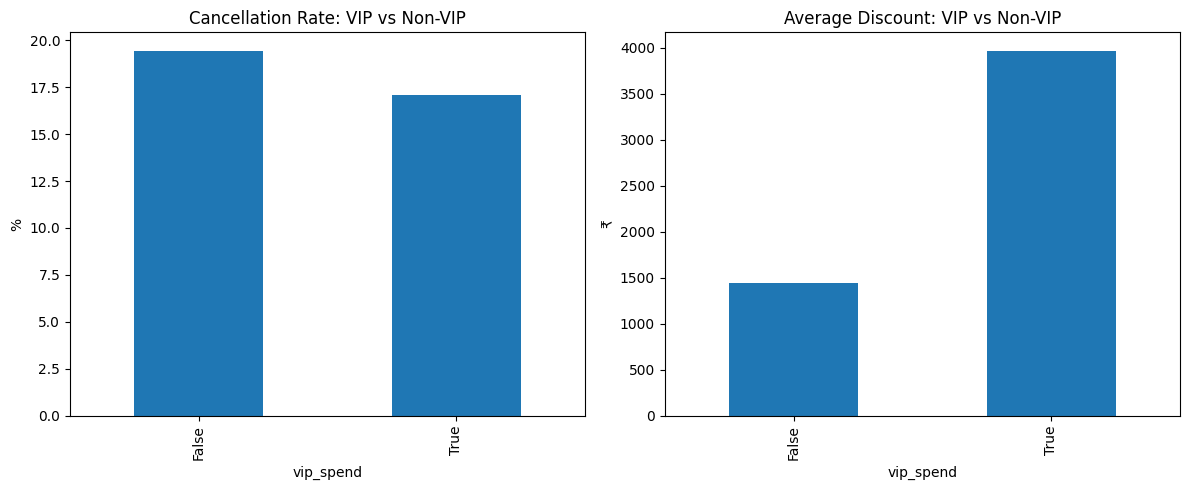

In [120]:
# Create separate chart for cleaner comparison

fig, ax = plt.subplots(1,2, figsize=(12,5))

# Cancellation Rate
cancel_rate.plot(
    kind='bar',
    ax=ax[0]
)

ax[0].set_title(
    'Cancellation Rate: VIP vs Non-VIP'
)

ax[0].set_ylabel('%')

# Discount Intensity
discount_intensity['avg_discount'].plot(
    kind='bar',
    ax=ax[1]
)

ax[1].set_title(
    'Average Discount: VIP vs Non-VIP'
)

ax[1].set_ylabel('₹')

plt.tight_layout()
plt.show()

**C3 Acquisition Math**

Now we'll calculate:

₹50 Lakhs ÷ ₹3,000 CAC

Number of new customers acquired

Average customer lifetime spend

Gross lifetime revenue generated

Year-1 revenue (20% assumption)

In [121]:
# Average customer lifetime spend
customer_lifetime_spend = (
    completed.groupby('customer_id')
    ['total_amount']
    .sum()
)

avg_lifetime_spend = (
    customer_lifetime_spend.mean()
)

print(
    "Average Lifetime Spend:",
    round(avg_lifetime_spend,2)
)

Average Lifetime Spend: 368574.74


Given
Budget = ₹50,00,000

CAC = ₹3,000 per customer

Average Lifetime Spend = ₹368,574.74

Year 1 Revenue = 20% of Lifetime Spend

In [122]:
# Total acquisition budget
budget = 5000000

# Customer Acquisition Cost (CAC)
cac = 3000

# Number of customers that can be acquired
new_customers = budget / cac

# Average lifetime spend from previous calculation
avg_lifetime_spend = 368574.74

# Gross lifetime revenue generated
gross_lifetime_revenue = (
    new_customers
    * avg_lifetime_spend
)

# Year 1 revenue assumption
# Customers generate 20% of lifetime spend in Year 1

year1_revenue = (
    gross_lifetime_revenue
    * 0.20
)

print("New Customers Acquired:", round(new_customers))
print("Gross Lifetime Revenue: ₹", round(gross_lifetime_revenue,2))
print("Year 1 Revenue: ₹", round(year1_revenue,2))

New Customers Acquired: 1667
Gross Lifetime Revenue: ₹ 614291233.33
Year 1 Revenue: ₹ 122858246.67


**C4 Retention Math**

In [123]:
# Total unique customers in the dataset

df['customer_id'].nunique()

800

Given

Retention Budget = ₹50,00,000

Retention Cost per Customer = ₹500

In [124]:
budget = 5000000

retention_cost = 500

# Theoretical customers that can be retained

customers_retained = (
    budget
    /
    retention_cost
)

print(
    "Customers Retained:",
    round(customers_retained)
)

Customers Retained: 10000


The budget exceeds the current customer base.

The platform cannot practically retain 10,000 existing customers because only 800 customers exist in the dataset.

In [125]:
# Average completed-booking revenue per customer

customer_revenue = (
    completed.groupby('customer_id')
    ['total_amount']
    .sum()
)

customer_revenue.describe()

,total_amount
count,8.000000e+02
mean,3.685747e+05
std,2.610938e+05
min,2.048646e+04
25%,2.042697e+05
50%,2.991344e+05
75%,4.362078e+05
max,1.939334e+06


Key Numbers

Average Customer Lifetime Spend = ₹368,575

Acquisition Cost (CAC) = ₹3,000

Retention Cost = ₹500

New Customers Acquired with ₹50L = 1,667

Customers Retained with ₹50L = 10,000 (theoretical)

Break-even retention success rate: 500 / 368575 × 100
≈ 0.14%

This means:

If retaining a customer worth ₹368,575 costs only ₹500, the retention campaign needs to save only 0.14% of that customer's value to break even.

That's extremely low.

**Acquisition ROI**

Cost to acquire one customer: 3,000

Expected lifetime value: 368,575

LTV:CAC Ratio = 368575 / 3000 ≈ 122.86

A ratio above 3 is usually considered good.

122.86 is exceptionally high.

**Sensitivity Analysis**

**Conservative Scenario **

Assume actual retained value is only:

10% of average lifetime spend

Then:

₹368,575 × 10%
≈ ₹36,858

Even then:

36,858 retained value
vs
500 retention cost

Retention remains highly attractive.

**Final Recommendation**

Because:

VIP customers generate 26.84% of revenue
VIP customers cancel less frequently (17.06% vs 19.45%)
Retention cost (₹500) is much lower than acquisition cost (₹3,000)
Break-even threshold is extremely low
Acquisition still provides strong long-term growth

A balanced strategy is preferable.

**Recommended Budget Split**

**Retention**
70%
₹35 Lakhs

**Acquisition**
30%
₹15 Lakhs

**Reason:**

Protect high-value existing customers.
Continue acquiring new customers for future growth.
Avoid over-investing in acquisition while valuable customers are at risk of churn.

## Section 2 Conclusion

The analysis supports prioritizing retention over acquisition because:

- VIP customers contribute 26.84% of realized revenue.
- VIP customers cancel less frequently than Non-VIPs.
- Retention cost (₹500) is substantially lower than acquisition cost (₹3,000).
- Break-even retention threshold is extremely low.

Recommended Budget Allocation:

- Retention: ₹35 Lakhs (70%)
- Acquisition: ₹15 Lakhs (30%)

This strategy balances immediate revenue protection with long-term customer growth.

---
# Section 3 – SQL Challenge